# Session 5 — Simple Linear Regression (Instagram Usage vs Battery)
---

## Question 1
**Create a Python script that generates two arrays: one representing the number of hours you spend on Instagram each day for a week, and the other representing your daily phone battery percentage at the end of the day. Plot these as a scatter plot using matplotlib.**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# Generate data for 7 days (Monday to Sunday)
# ============================================================

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Hours spent on Instagram each day
instagram_hours = np.array([1.5, 2.0, 3.5, 1.0, 4.0, 5.5, 6.0])

# Battery percentage at the end of the day
battery_percent = np.array([75, 65, 45, 80, 35, 20, 15])

# Display the data
print("WEEKLY DATA: Instagram Usage vs Battery")
print("=" * 50)
print(f"{'Day':<8} {'Instagram (hrs)':<20} {'Battery (%)'}")
print("-" * 50)
for d, h, b in zip(days, instagram_hours, battery_percent):
    print(f"{d:<8} {h:<20} {b}")

WEEKLY DATA: Instagram Usage vs Battery
Day      Instagram (hrs)      Battery (%)
--------------------------------------------------
Mon      1.5                  75
Tue      2.0                  65
Wed      3.5                  45
Thu      1.0                  80
Fri      4.0                  35
Sat      5.5                  20
Sun      6.0                  15


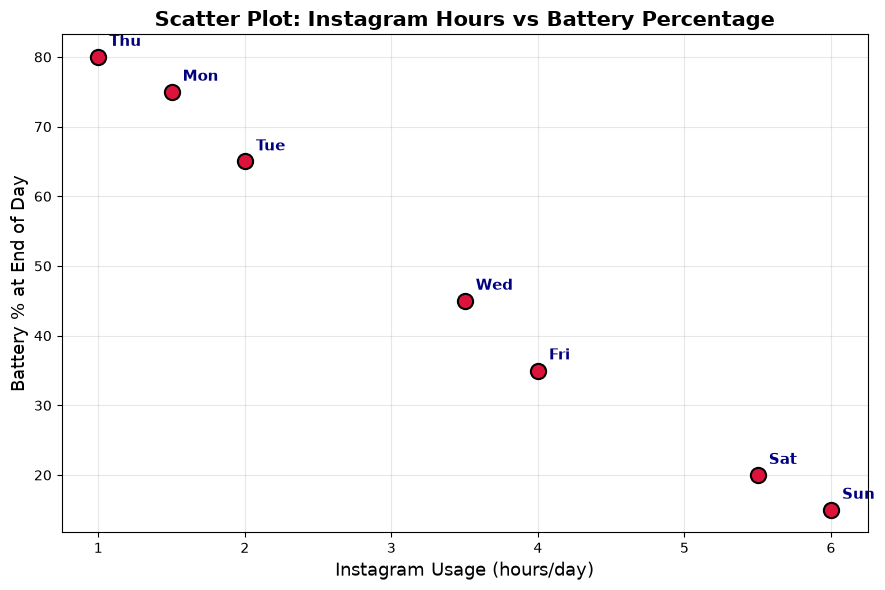

In [4]:
# Scatter Plot
plt.figure(figsize=(9, 6))
plt.scatter(instagram_hours, battery_percent, color='crimson', s=120,
            edgecolors='black', linewidths=1.5, zorder=5)

# Label each point with the day name
for i, day in enumerate(days):
    plt.annotate(day, (instagram_hours[i], battery_percent[i]),
                 textcoords='offset points', xytext=(8, 8),
                 fontsize=11, fontweight='bold', color='navy')

plt.xlabel('Instagram Usage (hours/day)', fontsize=13)
plt.ylabel('Battery % at End of Day', fontsize=13)
plt.title('Scatter Plot: Instagram Hours vs Battery Percentage', fontsize=15, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation
- There is a clear **negative relationship** — as Instagram usage increases, battery percentage decreases.
- This makes real-world sense: more screen time → more battery drain.

---
## Question 2
**Using scikit-learn's `LinearRegression`, fit a simple linear regression model to predict daily battery percentage based on Instagram usage hours from your generated data. Print the model's slope (coefficient) and intercept.**

In [5]:
from sklearn.linear_model import LinearRegression

# Reshape X for sklearn (needs 2D array)
X = instagram_hours.reshape(-1, 1)  # shape: (7, 1)
y = battery_percent                  # shape: (7,)

# Fit the Linear Regression model
model = LinearRegression()
model.fit(X, y)

# Extract slope and intercept
slope = model.coef_[0]
intercept = model.intercept_

print("LINEAR REGRESSION MODEL")
print("=" * 50)
print(f"Slope     (β₁) : {slope:.4f}")
print(f"Intercept (β₀) : {intercept:.4f}")
print(f"\nEquation: Battery% = {intercept:.4f} + ({slope:.4f}) × Instagram Hours")
print(f"\n📌 Interpretation:")
print(f"   • For every 1 hour increase in Instagram usage,")
print(f"     battery percentage drops by ~{abs(slope):.2f}%")
print(f"   • With 0 hours of Instagram, battery would be ~{intercept:.1f}%")

LINEAR REGRESSION MODEL
Slope     (β₁) : -13.3281
Intercept (β₀) : 92.6016

Equation: Battery% = 92.6016 + (-13.3281) × Instagram Hours

📌 Interpretation:
   • For every 1 hour increase in Instagram usage,
     battery percentage drops by ~13.33%
   • With 0 hours of Instagram, battery would be ~92.6%


---
## Question 3
**Plot the regression line on top of your scatter plot to visualize the relationship between Instagram hours and battery percentage using matplotlib.**

*Hint: Use `model.predict()` to get the predicted values for your x-axis data and plot them as a line.*

In [6]:
# Get predicted values using model.predict()
y_pred = model.predict(X)

# Print actual vs predicted
print("ACTUAL vs PREDICTED")
print("=" * 55)
print(f"{'Day':<8} {'Instagram (hrs)':<18} {'Actual (%)':<14} {'Predicted (%)'}")
print("-" * 55)
for d, h, actual, pred in zip(days, instagram_hours, battery_percent, y_pred):
    print(f"{d:<8} {h:<18} {actual:<14} {pred:.2f}")

ACTUAL vs PREDICTED
Day      Instagram (hrs)    Actual (%)     Predicted (%)
-------------------------------------------------------
Mon      1.5                75             72.61
Tue      2.0                65             65.95
Wed      3.5                45             45.95
Thu      1.0                80             79.27
Fri      4.0                35             39.29
Sat      5.5                20             19.30
Sun      6.0                15             12.63


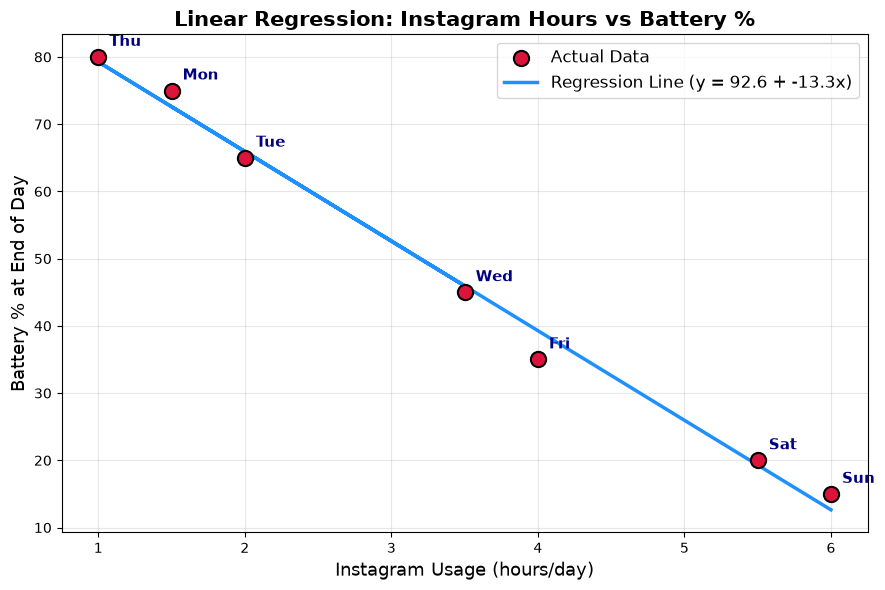

In [7]:
# Scatter plot + Regression line
plt.figure(figsize=(9, 6))

# Scatter points
plt.scatter(instagram_hours, battery_percent, color='crimson', s=120,
            edgecolors='black', linewidths=1.5, zorder=5, label='Actual Data')

# Regression line
plt.plot(instagram_hours, y_pred, color='dodgerblue', linewidth=2.5,
         linestyle='-', label=f'Regression Line (y = {intercept:.1f} + {slope:.1f}x)')

# Label each point
for i, day in enumerate(days):
    plt.annotate(day, (instagram_hours[i], battery_percent[i]),
                 textcoords='offset points', xytext=(8, 8),
                 fontsize=11, fontweight='bold', color='navy')

plt.xlabel('Instagram Usage (hours/day)', fontsize=13)
plt.ylabel('Battery % at End of Day', fontsize=13)
plt.title('Linear Regression: Instagram Hours vs Battery %', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observation
- The blue **regression line** passes through the data points showing a clear **downward trend**.
- The line captures the negative relationship well — more Instagram hours → lower battery.
- Some points are above the line, some below — the vertical distance from each point to the line is the **residual (error)**.

---
## Question 4
**Calculate the mean squared error (MSE) between your actual battery percentages and the predicted values from your regression model using `sklearn.metrics.mean_squared_error`. Print the MSE value and explain in one line what a lower MSE indicates.**

In [8]:
from sklearn.metrics import mean_squared_error, r2_score

# Calculate MSE
mse = mean_squared_error(battery_percent, y_pred)

# Also calculate RMSE and R² for additional context
rmse = np.sqrt(mse)
r2 = r2_score(battery_percent, y_pred)

print("MODEL EVALUATION")
print("=" * 50)
print(f"Mean Squared Error  (MSE)  : {mse:.4f}")
print(f"Root Mean Sq Error  (RMSE) : {rmse:.4f}")
print(f"R² Score                   : {r2:.4f}")
print(f"\n{'='*50}")
print(f"📌 What does a lower MSE indicate?")
print(f"   A lower MSE means the model's predictions are")
print(f"   closer to the actual values — i.e., the model")
print(f"   fits the data better with smaller errors.")

MODEL EVALUATION
Mean Squared Error  (MSE)  : 4.6484
Root Mean Sq Error  (RMSE) : 2.1560
R² Score                   : 0.9920

📌 What does a lower MSE indicate?
   A lower MSE means the model's predictions are
   closer to the actual values — i.e., the model
   fits the data better with smaller errors.


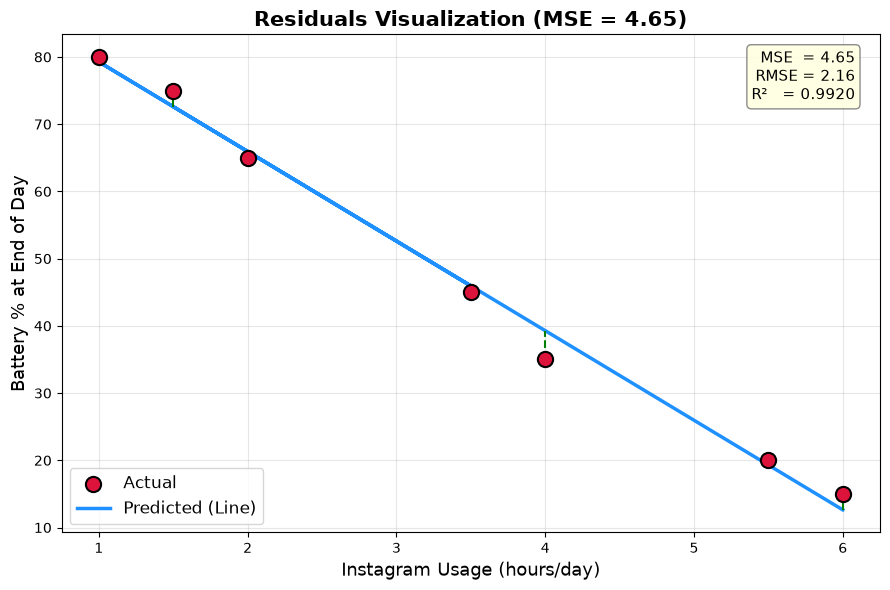

In [9]:
# Visualize the errors (residuals)
residuals = battery_percent - y_pred

plt.figure(figsize=(9, 6))

# Scatter + Regression line
plt.scatter(instagram_hours, battery_percent, color='crimson', s=120,
            edgecolors='black', linewidths=1.5, zorder=5, label='Actual')
plt.plot(instagram_hours, y_pred, color='dodgerblue', linewidth=2.5, label='Predicted (Line)')

# Draw error lines from actual to predicted
for i in range(len(instagram_hours)):
    plt.vlines(x=instagram_hours[i], ymin=min(battery_percent[i], y_pred[i]),
               ymax=max(battery_percent[i], y_pred[i]),
               color='green', linewidth=1.5, linestyle='--')

plt.xlabel('Instagram Usage (hours/day)', fontsize=13)
plt.ylabel('Battery % at End of Day', fontsize=13)
plt.title(f'Residuals Visualization (MSE = {mse:.2f})', fontsize=15, fontweight='bold')
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

# Add text box with MSE
textstr = f'MSE  = {mse:.2f}\nRMSE = {rmse:.2f}\nR²   = {r2:.4f}'
plt.text(0.97, 0.97, textstr, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray', alpha=0.9))

plt.tight_layout()
plt.show()

### Explanation

**MSE (Mean Squared Error):**

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

| Term | Meaning |
|------|---------|
| $y_i$ | Actual battery percentage |
| $\hat{y}_i$ | Predicted battery percentage |
| $n$ | Number of data points (7 days) |

- The **green dashed lines** in the plot above represent the errors (residuals) for each data point.
- MSE squares these errors and averages them.
- **A lower MSE indicates that the model's predictions are closer to the actual values**, meaning the regression line fits the data better.